# Integração Numérica da Distância de Luminosidade pela Métrica de Hogg em Modelos FLRW

Este notebook apresenta a rotina de integração numérica para o cálculo da Distância de Luminosidade ($D_L$) e do Módulo de Distância ($\mu$) baseada na formulação de Hogg para modelos cosmológicos de Friedmann-Lemaître-Robertson-Walker (FLRW).

**Autor:** Victor Moreira Acacio

---

## Fundamentação Teórica e Parâmetros

A evolução da taxa de expansão do universo em função do redshift $z$ é descrita pela função de expansão $E(z)$, que depende dos parâmetros de densidade para a matéria ($\Omega_m$), curvatura ($\Omega_k$) e energia escura ($\Omega_{EE}$), considerando sua equação de estado $w$:

$$E(z) = \sqrt{\Omega_m(1+z)^3 + \Omega_k(1+z)^2 + \Omega_{EE}(1+z)^{3(1+w)}}$$

A partir de $E(z)$, a distância comóvel radial (linha de visada) $D_C$ é obtida através da integração:

$$D_C = \frac{c}{H_0} \int_0^z \frac{dz'}{E(z')}$$

BIBLIOTECAS E DEPENDÊNCIAS

In [12]:
from astropy import constants as const
import numpy as np
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from scipy.integrate import quad
from pathlib import Path as path
from matplotlib.ticker import AutoMinorLocator

PARAMETERS - Parâmetros modificáveis para a simulação

In [13]:

# * =============================================================================
# * PARÂMETROS INICIAIS
# * =============================================================================

Omega_M = 0.315  # Densidade de matéria [adm.]
Omega_EE = 0.685  # Densidade de energia escura [adm.]
w = -1  # Parâmetro de equação de estado da energia escura [adm.]
z = 10  # Redshift máximo [adm.]

# * =============================================================================
# * PARÂMETROS DE ANÁLISE
# * =============================================================================

# ? -----------------------------------------------------------------------------
# ?         MAIN
# ? -----------------------------------------------------------------------------

z_step = 10e-4  # Intervalo entre um ponto e outro nos dados

# ? -----------------------------------------------------------------------------
# ?         INFERENCE
# ? -----------------------------------------------------------------------------

mesh_inter_omega = [0, 1]  # Intervalo de análise [omega_ini, omega_fin]
mesh_inter_w = [-1.25, 0.25]  # Intervalo de análise [w_ini, w_fin]
meshgrid_step = 10e-3  # Intervalo entre um ponto e outro nos dados
Omega_K_obs = -0.06  # Parâmetro de Densidade da Curvatura observado
ERROOmega_K_obs = 0.05  # Erro do Parâmetro de Densidade da Curvatura observado


CONSTANTS - Constantes utilizadas dentro do código

In [14]:

# * =============================================================================
# * CONSTANTES FÍSICAS
# * =============================================================================

H0 = 70  # Constante de Hubble [km/s/Mpc]
c = const.c.to("km/s").value  # Velocidade da luz [km/s]


SYSTEM - Funções de Configuração geral do sistema

In [15]:

# * =============================================================================
# * FUNÇÕES DE ATUALIZAÇÃO DE SISTEMA
# * =============================================================================


def header(titulo, largura=60, **kwargs):
    """Função responsável por criar um output-status em estilo de título de seção."""
    print("\n" + "=" * largura)
    print(f"{titulo.upper():^{largura}}")
    if kwargs:
        info_str = "  |  ".join([f"{k}: {v}" for k, v in kwargs.items()])
        print(f"{info_str:^{largura}}")
    print("-" * largura)


def status(msg):
    """Função responsável por criar um output-status em estilo de status."""
    print(f"\n  > {msg}...")


def param(nome, valor, unidade=""):
    """Função responsável por criar um output-status em estilo de informar parâmetros."""
    unit_str = f" [{unidade}]" if unidade else ""
    print(f"      {nome} = {valor}{unit_str}")


def bar(largura=60):
    """Função responsável por criar um output-status em estilo de barra de divisão."""
    print("\n")
    print("◇" * largura)
    print("\n")


SAVE_LOAD - Rotinas de exportações e importações de dados

In [16]:

# * =============================================================================
# * FUNÇÕES DE SALVAMENTO
# * =============================================================================


def save_data(
    nome_arquivo="data",
    decimais=10,
    vecX=[],
    vecY=[],
    description="",
    dominio_inferior=0.0,
    dominio_superior=0.0,
    x_grand="",
    x_unit="",
    y_grand="",
    y_unit="",
):
    """Função responsável por salvar um determinado conjunto de dados em um arquivo.txt"""
    data = np.column_stack((vecX, vecY))
    header_text = (
        f"Descripiton: {description}\n"
        f"Domain: {x_grand} in [{dominio_inferior}, {dominio_superior}]\n"
        f"Units: {x_grand} [{x_unit}], {y_grand} [{y_unit}] \n"
        f"{x_grand},{y_grand}"
    )
    folderData = path("data")
    folderData.mkdir(parents=True, exist_ok=True)
    np.savetxt(
        f"{folderData}/{nome_arquivo}.txt",
        data,
        fmt=f"%.{decimais}f",
        delimiter=",",
        header=header_text,
        comments="# ",
    )


# * =============================================================================
# * FUNÇÕES DE CARREGAMENTO
# * =============================================================================


def load_data(caminho_arquivo):
    """
    Lê um arquivo .txt formatado com cabeçalhos '#' e separado por vírgulas.
    Retorna dois vetores (vetor X e vetor Y).
    """
    try:
        vetor_x, vetor_y = np.loadtxt(caminho_arquivo, delimiter=",", unpack=True)
        return vetor_x, vetor_y
    except FileNotFoundError:
        print(f"Erro: O arquivo '{caminho_arquivo}' não foi encontrado.")
        return [], []
    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
        return [], []


def load_obs_data(caminho_arquivo):
    """
    Lê um arquivo .txt não formatado e separado por espaços.
    Retorna três vetores (vetor X, vetor Y, vetor Z).
    """
    try:
        vetor_x, vetor_y, vetor_z = np.loadtxt(
            caminho_arquivo, delimiter=" ", unpack=True
        )
        return vetor_x, vetor_y, vetor_z
    except FileNotFoundError:
        print(f"Erro: O arquivo '{caminho_arquivo}' não foi encontrado.")
        return None
    except Exception as e:
        print(f"Erro ao ler o arquivo: {e}")
        return None


PLOT - Rotinas responsáveis por gerar gráficos

In [17]:

# * =============================================================================
# * FUNÇÕES DE CRIAÇÃO DE GRÁFICOS
# * =============================================================================


# ? -----------------------------------------------------------------------------
# ?         GRÁFICO COMUM
# ? -----------------------------------------------------------------------------


def plot(
    save, x, y, save_name="", titulo_x="X", titulo_y="Y", tam_fonte=14, espessura=2.5
):
    """Função responsável por plotar gráficos com o estilo padrão LaTeX/Científico."""
    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "dejavuserif",
            "axes.labelsize": tam_fonte,
            "font.size": tam_fonte,
            "xtick.labelsize": tam_fonte - 2,
            "ytick.labelsize": tam_fonte - 2,
            "axes.linewidth": 1.2,
        }
    )
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    ax.plot(x, y, linewidth=espessura, color="black", linestyle="-")
    ax.set_title("", fontsize=tam_fonte + 2, pad=15)
    ax.set_xlabel(titulo_x, labelpad=8)
    ax.set_ylabel(titulo_y, labelpad=8)
    ax.tick_params(
        which="major", direction="in", length=6, width=1.2, top=True, right=True
    )
    ax.tick_params(
        which="minor", direction="in", length=3, width=1.0, top=True, right=True
    )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
    ax.grid(False)
    plt.tight_layout()
    if save == True:
        folderData = path("figures")
        folderData.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            folderData / f"{save_name.replace(' ', '')}.pdf",
            bbox_inches="tight",
            dpi=600,
            facecolor="white",
            transparent=False,
        )
    plt.show()


# ? -----------------------------------------------------------------------------
# ?         GRÁFICO DE SUPERPOSIÇÃO DE TRÊS CURVAS
# ? -----------------------------------------------------------------------------


def ppplot(
    save,
    x1,
    y1,
    x2,
    y2,
    x3,
    y3,
    label1="Modelo1",
    label2="Modelo2",
    label3="Modelo3",
    save_name="",
    titulo_x="X",
    titulo_y="Y",
    tam_fonte=14,
    espessura=2.5,
):
    """Função responsável por plotar gráficos sobrepostos com o estilo padrão LaTeX/Científico."""
    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "dejavuserif",
            "axes.labelsize": tam_fonte,
            "font.size": tam_fonte,
            "xtick.labelsize": tam_fonte - 2,
            "ytick.labelsize": tam_fonte - 2,
            "axes.linewidth": 1.2,
        }
    )
    fig, ax = plt.subplots(figsize=(8, 6), dpi=100)
    ax.plot(x1, y1, linewidth=espessura, color="black", linestyle="-", label=label1)
    ax.plot(x2, y2, linewidth=espessura, color="black", linestyle="--", label=label2)
    ax.plot(x3, y3, linewidth=espessura, color="black", linestyle=":", label=label3)
    ax.set_title("", fontsize=tam_fonte + 2, pad=15)
    ax.set_xlabel(titulo_x, labelpad=8)
    ax.set_ylabel(titulo_y, labelpad=8)
    ax.tick_params(
        which="major", direction="in", length=6, width=1.2, top=True, right=True
    )
    ax.tick_params(
        which="minor", direction="in", length=3, width=1.0, top=True, right=True
    )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
    ax.grid(False)
    ax.legend(
        fontsize=tam_fonte - 2,
        frameon=False,
        fancybox=False,
        shadow=False,
        edgecolor="black",
        loc="best",
    )
    plt.tight_layout()
    if save == True:
        folderData = path("figures")
        folderData.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            folderData / f"{save_name.replace(' ','')}.pdf",
            bbox_inches="tight",
            dpi=600,
            facecolor="white",
            transparent=False,
        )
    plt.show()


# ? -----------------------------------------------------------------------------
# ?         GRÁFICO DE ELIPSES COM CURVAS DE NÍVEIS
# ? -----------------------------------------------------------------------------


def elipse_plot(
    save,
    x_list,
    y_list,
    z_matrix,
    levels,
    save_name="",
    titulo_x=r"$\Omega_M$",
    titulo_y=r"$\Omega_{EE}$",
    tam_fonte=14,
):
    """
    Função para plotar contornos de confiança (elipses) no estilo padrão LaTeX.
    Recebe x_list e y_list (eixos da malha) e z_matrix (matriz de Chi2).
    """
    plt.rcParams.update(
        {
            "font.family": "serif",
            "mathtext.fontset": "dejavuserif",
            "axes.labelsize": tam_fonte,
            "font.size": tam_fonte,
            "xtick.labelsize": tam_fonte - 2,
            "ytick.labelsize": tam_fonte - 2,
            "axes.linewidth": 1.2,
        }
    )
    fig, ax = plt.subplots(figsize=(8, 7), dpi=100)
    contorno = ax.contour(
        x_list,
        y_list,
        z_matrix.T,
        levels=levels,
        colors=["#1f77b4", "#ff7f0e", "#2ca02c"],
        linewidths=2.0,
    )
    fmt = {levels[0]: r"1$\sigma$", levels[1]: r"2$\sigma$", levels[2]: r"3$\sigma$"}
    ax.clabel(contorno, inline=True, fontsize=tam_fonte - 4, fmt=fmt)
    x_plano = np.linspace(min(x_list), max(x_list), 100)
    ax.plot(
        x_plano,
        1 - x_plano,
        color="black",
        linestyle="--",
        alpha=0.6,
        label="Universo Plano",
    )
    ax.set_xlabel(titulo_x, labelpad=8)
    ax.set_ylabel(titulo_y, labelpad=8)
    ax.tick_params(
        which="major", direction="in", length=6, width=1.2, top=True, right=True
    )
    ax.tick_params(
        which="minor", direction="in", length=3, width=1.0, top=True, right=True
    )
    ax.xaxis.set_minor_locator(AutoMinorLocator())
    ax.yaxis.set_minor_locator(AutoMinorLocator())
    idx_m, idx_ee = np.unravel_index(np.argmin(z_matrix), z_matrix.shape)
    ax.plot(x_list[idx_m], y_list[idx_ee], "rx", markersize=8, label="Best Fit")
    ax.legend(fontsize=tam_fonte - 2, frameon=False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")
    plt.tight_layout()
    if save == True:
        folderData = path("figures")
        folderData.mkdir(parents=True, exist_ok=True)
        plt.savefig(
            folderData / f"{save_name.replace(' ', '')}.pdf",
            bbox_inches="tight",
            dpi=600,
            facecolor="white",
            transparent=False,
        )
    plt.show()


CORE - Núcleo Matemático

In [18]:

# * =============================================================================
# * FUNÇÕES MATEMÁTICAS
# * =============================================================================

# ? -----------------------------------------------------------------------------
# ?         FUNÇÕES FÍSICAS
# ? -----------------------------------------------------------------------------


def q0(Omega_M, Omega_EE, w):
    """Calcula o parâmetro de desaceleração atual (q0) a partir dos parâmetros de densidade de matéria e energia escura."""
    return 0.5 * Omega_M + 0.5 * Omega_EE * (1 + 3 * w)


def dL(Omega_M, Omega_EE, resint, z):
    """Calcula a distância de luminosidade (dL) a partir da distância comóvel transversal (dm) e do redshift (z)."""
    return (1 + z) * dm(Omega_M, Omega_EE, resint)


def approx_dL(Omega_M, Omega_EE, z, w):
    """Calcula a aproximação de distância de luminosidade (dL) para pequenos redshifts (z) usando o parâmetro de desaceleração (q0)."""
    return (c / H0) * z * (1 + (1 - q0(Omega_M, Omega_EE, w)) * z / 2)


def Omega_K(Omega_M, Omega_EE):
    """Calcula o parâmetro de curvatura (Omega_K) a partir dos parâmetros de densidade de matéria e energia escura."""
    return 1 - (Omega_M + Omega_EE)


def mu(Omega_M, Omega_EE, resint, z):
    """Calcula a magnitude de distância (mu) a partir da distância de luminosidade (dL) e do redshift (z)."""
    return 5 * np.log10(dL(Omega_M, Omega_EE, resint, z)) + 25


def E(z, Omega_M, Omega_EE, w):
    """Calcula a função de expansão (E) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura."""
    return np.sqrt(
        Omega_M * (1 + z) ** 3
        + Omega_EE * (1 + z) ** (3 * (1 + w))
        + Omega_K(Omega_M, Omega_EE) * (1 + z) ** 2
    )


def Sk(Omega_M, Omega_EE, r):
    """Calcula a função de distância comóvel transversal (Sk) a partir do parâmetro de curvatura (k) e da distância comóvel radial (r)."""
    Ok = Omega_K(Omega_M, Omega_EE)
    DH = c / H0
    if Ok > 0:
        return (DH / np.sqrt(Ok)) * np.sinh(np.sqrt(Ok) * r / DH)
    elif Ok < 0:
        return (DH / np.sqrt(-Ok)) * np.sin(np.sqrt(-Ok) * r / DH)
    else:
        return r


def dm(Omega_M, Omega_EE, resint):
    """Calcula a distância comóvel transversal (dm) a partir do parâmetro de curvatura (k) e da distância comóvel radial (dC)."""
    return Sk(Omega_M, Omega_EE, dC(resint))


def dC(resint):
    """Calcula o valor de distância comóvel radial (dC) a partir do resultado da integração dda função integral."""
    return (c / H0) * resint


def k(Omega_M, Omega_EE):
    """Determina o parâmetro de curvatura com base no valor do Parâmetro de Densidade de Curvatura (Omega_k)"""
    Ok = Omega_K(Omega_M, Omega_EE)
    if Ok > 0:
        return -1
    elif Ok < 0:
        return +1
    else:
        return 0


# ? -----------------------------------------------------------------------------
# ?         FUNÇÕES SISTEMÁTICAS DE CÁLCULO NO MAIN
# ? -----------------------------------------------------------------------------


def integral(z, Omega_M, Omega_EE, w):
    """Formaliza a quantidade a ser integrada para o cálculo da distância comóvel radial (dC) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura."""
    return 1 / E(z, Omega_M, Omega_EE, w)


def integracao(integral, Omega_M, Omega_EE, z, w):
    IntANDError = quad(integral, 0, z, args=(Omega_M, Omega_EE, w))
    resint = IntANDError[0]
    ERRORresint = IntANDError[1]
    return [resint, ERRORresint]


def UniType(Omega_k):
    """Determina o tipo de universo estudado baseado no valor do Parâmetro de Densidade de Curvatura(Omega_k)"""
    if Omega_k > 0:
        return "Universo Aberto"
    elif Omega_k < 0:
        return "Universo Fechado"
    else:
        return "Universo Plano"


def solution(Omega_M, Omega_EE, z, z_step, w):
    """Função que calcula uma matriz de resultados de distância de luminosidade (dL), módulo de distância (mu), distância de luminosidade aproximada (dLAP) e diferença entre as duas (DIF) a partir do redshift (z) e dos parâmetros de densidade de matéria e energia escura em um passo (z_step)."""
    DLvectorX = []
    DLvectorY = []
    MUvectorX = []
    MUvectorY = []
    DLAPvectorX = []
    DLAPvectorY = []
    DIFvectorX = []
    DIFvectorY = []
    for i in tqdm(np.arange(float(z_step), float(z) + float(z_step), float(z_step))):
        iresint = integracao(integral, Omega_M, Omega_EE, i, w)
        DLvectorX.append(i)
        DLvectorY.append(dL(Omega_M, Omega_EE, iresint[0], i))
        MUvectorX.append(i)
        MUvectorY.append(mu(Omega_M, Omega_EE, iresint[0], i))
        DLAPvectorX.append(i)
        DLAPvectorY.append(approx_dL(Omega_M, Omega_EE, i, w))
        if i <= 1:
            DIFvectorX.append(i)
            DIFvectorY.append(DLvectorY[-1] - DLAPvectorY[-1])
    return [
        DLvectorX,
        DLvectorY,
        MUvectorX,
        MUvectorY,
        DLAPvectorX,
        DLAPvectorY,
        DIFvectorX,
        DIFvectorY,
    ]


# ? -----------------------------------------------------------------------------
# ?         FUNÇÕES SISTEMÁTICAS DE CÁLCULO NO INFERENCE
# ? -----------------------------------------------------------------------------


def chi2(mu_obs_list, ERROmu_obs_list, mu_teo_list):
    """Função responsável por calcular o qui-quadrado para uma lista de módulos de distância (mu) observados (mu_obs_list), seus erros (ERROmu_obs_list) e os módulos de distância teoricos (mu_teo_list)."""
    x = (mu_obs_list - mu_teo_list) / (ERROmu_obs_list)
    return np.sum(x**2)


def malha_mu_teo(Omega_M, Omega_EE, z_list, w):
    """Função responsável por calcular uma lista de módulos de distância (mu) teoricos para uma lista de redshifts (z_list)."""
    mu_teo_list = []
    for z in z_list:
        mu_teo_list.append(
            mu(
                Omega_M,
                Omega_EE,
                integracao(integral, Omega_M, Omega_EE, z, w)[0],
                z,
            )
        )
    return mu_teo_list


def varredura_1D(omega_list, mu_obs_list, ERROmu_obs_list, z_list, w):
    """Função responsável por realizar uma varredura 1D (Universo Plano) para calcular o qui-quadrado para uma lista de módulos de distância (mu) observados (mu_obs_list), seus erros (ERROmu_obs_list) e os módulos de distância teoricos (mu_teo_list)."""
    chi2_list = []
    for om in tqdm(omega_list, desc="PROGRESSO"):
        oee = 1 - om
        chi2_list.append(
            chi2(mu_obs_list, ERROmu_obs_list, malha_mu_teo(om, oee, z_list, w))
        )
    return [chi2_list, omega_list, 1 - np.array(omega_list)]


def varredura_2D(omegaM_list, omegaEE_list, mu_obs_list, ERROmu_obs_list, z_list, w):
    """Função responsável por realizar uma varredura 2D (Universo com Curvatura Livre) para calcular o qui-quadrado para uma lista de módulos de distância (mu) observados (mu_obs_list), seus erros (ERROmu_obs_list) e os módulos de distância teoricos (mu_teo_list)."""
    matriz_chi2 = np.zeros((len(omegaM_list), len(omegaEE_list)))
    for i, om in enumerate(tqdm(omegaM_list, desc="PROGRESSO")):
        for j, oee in enumerate(omegaEE_list):
            mu_teorico = malha_mu_teo(om, oee, z_list, w)
            matriz_chi2[i, j] = chi2(mu_obs_list, ERROmu_obs_list, mu_teorico)
    return matriz_chi2


def quebra_degenerecencia(
    omegaM_list, omegaEE_list, matriz_sn, omegaK_obs, ERROomegaK_obs
):
    """
    Aplica o Prior da CMB sobre a matriz de Chi2 das Supernovas.
    ok_obs e sigma_ok devem seguir o roteiro do IAG (geralmente Planck).
    """
    matriz_total = np.zeros_like(matriz_sn)
    for i, om in enumerate(omegaM_list):
        for j, oee in enumerate(omegaEE_list):
            ok_teo = 1 - (om + oee)
            chi2_cmb = ((ok_teo - omegaK_obs) ** 2) / (ERROomegaK_obs**2)
            matriz_total[i, j] = matriz_sn[i, j] + chi2_cmb
    return matriz_total


def veross1d(chi2_list, chi_min, omegaEE_list):
    """Calcula a probabilidade de Omega_EE > 0.5 para o caso 1D (Universo Plano)."""
    L_vector = np.exp(-(np.array(chi2_list) - chi_min) / 2)
    mask_ee = np.array(omegaEE_list) > 0.5
    soma_total = np.sum(L_vector)
    soma_ee_05 = np.sum(L_vector[mask_ee])
    prob_ee = soma_ee_05 / soma_total
    return prob_ee


def veross2d(var2dPRIOR, chi2d_minPRIOR, omegaM_list, omegaEE_list, w):
    """Função responsável por calcular a probabilidade de aceleração para o universo com curvatura livre."""
    L_matrix = np.exp(-(var2dPRIOR - chi2d_minPRIOR) / 2)
    OM, OEE = np.meshgrid(omegaM_list, omegaEE_list, indexing="ij")
    mask_acel = q0(OM, OEE, w) < 0
    soma_total = np.sum(L_matrix)
    soma_acelerada = np.sum(L_matrix[mask_acel])
    prob_aceleracao = soma_acelerada / soma_total
    return prob_aceleracao


def varreduraOW(w_list, omegaM_list, mu_obs_list, ERROmu_obs_list, z_list):
    """Função responsável por gerar uma matriz de chi2 para cada combinação de omega_M e w para um universo plano."""
    matriz_chi2 = np.zeros((len(w_list), len(omegaM_list)))
    for i, w in enumerate(tqdm(w_list, desc="PROGRESSO")):
        for j, om in enumerate(omegaM_list):
            oe = 1-om
            mu_teorico = malha_mu_teo(om, oe, z_list, w)
            matriz_chi2[i, j] = chi2(mu_obs_list, ERROmu_obs_list, mu_teorico)
    return matriz_chi2


MAIN - Simula o modelo FLRW

In [19]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================


def main(Omega_M, Omega_EE, w, z, z_step, type="return"):
    header(
        "iniciando HoggCosmoMeasures...", Omega_M=Omega_M, Omega_EE=Omega_EE, w=w, z=z
    )

    # ? -----------------------------------------------------------------------------
    # ?         CÁLCULO DE PARÂMETROS PONTUAIS
    # ? -----------------------------------------------------------------------------

    try:
        status("Iniciando processo de integração numérica para parâmetros pontuais")
        resintlist = integracao(integral, Omega_M, Omega_EE, z, w)
        status(
            "Processo de integração numérica para parâmetros pontuais finalizado com sucesso!"
        )
        param("Integração Numérica", resintlist[0], "Mpc")
        param("Erro Estimado", resintlist[1], "Mpc")
        param(
            "Distância de Luminosidade para 'z' (dL(z))",
            dL(Omega_M, Omega_EE, resintlist[0], z),
            "Mpc",
        )
        param(
            "Módulo de Distância para 'z' (mu(z))",
            mu(Omega_M, Omega_EE, resintlist[0], z),
            "mag",
        )
    except Exception as e:
        status(f"Processo de integração numérica falhou! Erro: {e}")
    status("Iniciando cálculo de parâmetros do universo")
    param("Tipo de universo", UniType(Omega_K(Omega_M, Omega_EE)))
    param("Constante de curvatura espacial (k)", k(Omega_M, Omega_EE))
    param("Parâmetro derivado de curvatura (Omega_K)", Omega_K(Omega_M, Omega_EE))
    param("Distância comóvel radial (dC)", dC(resintlist[0]), "Mpc")
    param("Parâmetro de desaceleração (q0)", q0(Omega_M, Omega_EE, w))

    # ? -----------------------------------------------------------------------------
    # ?         CÁLCULO DE PARÂMETROS PARA TODO O INTERVALO
    # ? -----------------------------------------------------------------------------

    try:
        status("Iniciando integração por todo o intervalo de redshift")
        sollist = solution(Omega_M, Omega_EE, z, z_step, w)
        DLvectorX = sollist[0]
        DLvectorY = sollist[1]
        MUvectorX = sollist[2]
        MUvectorY = sollist[3]
        DLAPvectorX = sollist[4]
        DLAPvectorY = sollist[5]
        DIFvectorX = sollist[6]
        DIFvectorY = sollist[7]
        status("Integração por todo o intervalo de redshift finalizada com sucesso!")

        # ? -----------------------------------------------------------------------------
        # ?         EXPORTAÇÃO DE DADOS
        # ? -----------------------------------------------------------------------------

        if type == "custom":
            status("Iniciando exportação de dados")
            save_data(
                f"DLdados",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdados",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdados",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdados",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        elif type == "M":
            status("Iniciando exportação de dados")
            save_data(
                f"DLdadosM",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdadosM",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdadosM",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdadosM",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        elif type == "EE":
            status("Iniciando exportação de dados")
            save_data(
                f"DLdadosEE",
                10,
                DLvectorX,
                DLvectorY,
                "Distribuicao de Distancia de Luminosidade",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"MUdadosEE",
                10,
                MUvectorX,
                MUvectorY,
                "Distribuicao de Modulo de Distancia",
                0,
                10,
                "z",
                "adm.",
                "mu",
                "mag",
            )
            save_data(
                f"DLAPdadosEE",
                10,
                DLAPvectorX,
                DLAPvectorY,
                "Distribuicao de Distancia de Luminosidade Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
            save_data(
                f"DIFdadosEE",
                10,
                DIFvectorX,
                DIFvectorY,
                "Analise de Erro na Distribuicao de Distancia de Luminosidade exata e Aproximada",
                0,
                10,
                "z",
                "adm.",
                "dL",
                "Mpc",
            )
        elif type == "return":
            status("Rotina principal finalizada!")
            return [
                dL(Omega_M, Omega_EE, resintlist[0], z),
                mu(Omega_M, Omega_EE, resintlist[0], z),
            ]
        status("Exportação de dados concluida com sucesso!")
        status("Rotina principal finalizada!")
    except Exception as e:
        status(f"Falha no processo de salvamento! Erro: {e}")


# ? -----------------------------------------------------------------------------
# ?         MAIN GUARD
# ? -----------------------------------------------------------------------------


if __name__ == "__main__":
    main(Omega_M, Omega_EE, w, z, z_step, type="custom")



               INICIANDO HOGGCOSMOMEASURES...               
   Omega_M: 0.315  |  Omega_EE: 0.685  |  w: -1  |  z: 10   
------------------------------------------------------------

  > Iniciando processo de integração numérica para parâmetros pontuais...

  > Processo de integração numérica para parâmetros pontuais finalizado com sucesso!...
      Integração Numérica = 2.1658774268377683 [Mpc]
      Erro Estimado = 1.867051910489849e-12 [Mpc]
      Distância de Luminosidade para 'z' (dL(z)) = 102035.01275289296 [Mpc]
      Módulo de Distância para 'z' (mu(z)) = 50.04374611548499 [mag]

  > Iniciando cálculo de parâmetros do universo...
      Tipo de universo = Universo Plano
      Constante de curvatura espacial (k) = 0
      Parâmetro derivado de curvatura (Omega_K) = 0.0
      Distância comóvel radial (dC) = 9275.910250262996 [Mpc]
      Parâmetro de desaceleração (q0) = -0.5275000000000001

  > Iniciando integração por todo o intervalo de redshift...


  0%|          | 0/10000 [00:00<?, ?it/s]


  > Integração por todo o intervalo de redshift finalizada com sucesso!...

  > Iniciando exportação de dados...

  > Exportação de dados concluida com sucesso!...

  > Rotina principal finalizada!...


BASIC_PLOTS - Plots do Universo simulado customizado em parâmetros


                  INICIANDO BASIC PLOTS...                  
------------------------------------------------------------


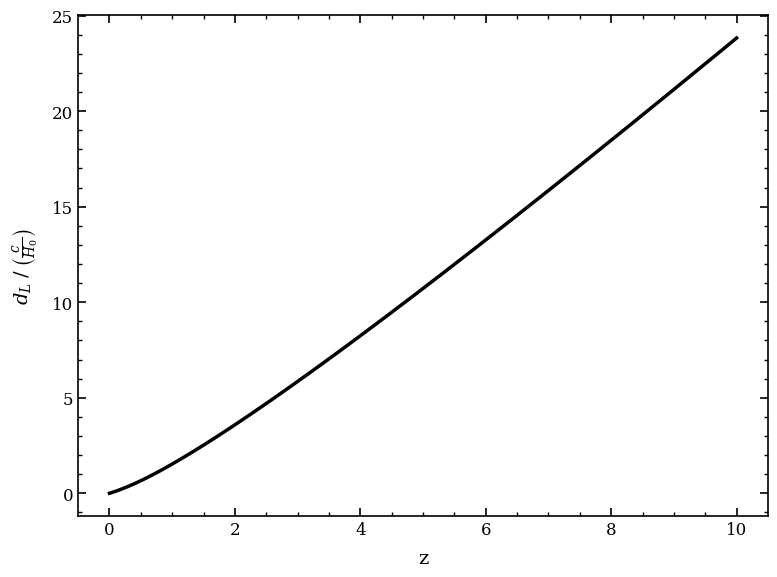

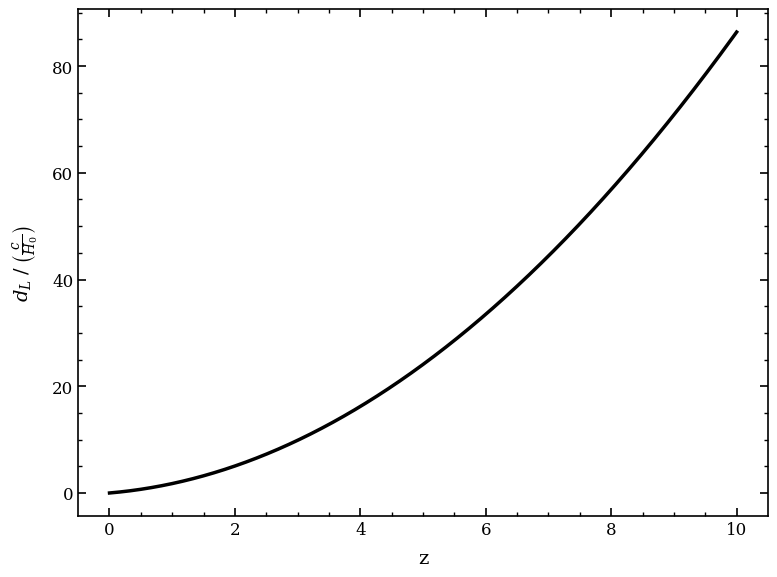

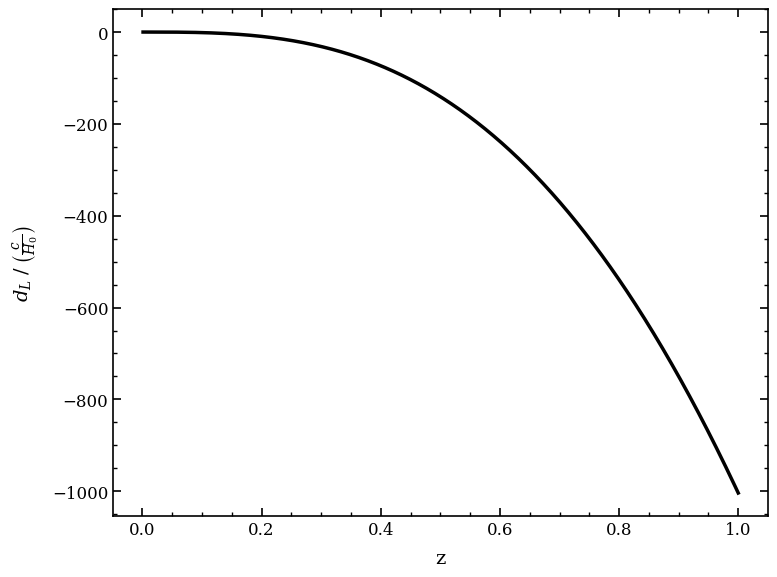

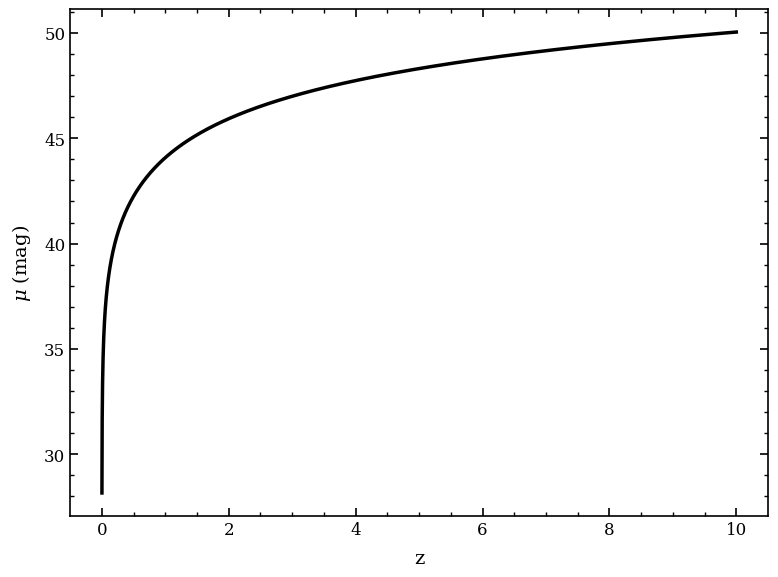


  > Criação e salvamento dos gráficos concluida com sucesso!...

  > Rotina de criação de gráficos finalizada...


In [20]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

header("Iniciando basic plots...")

# ? -----------------------------------------------------------------------------
# ?         CARREGANDO DADOS DO UNIVERSO SIMULADO
# ? -----------------------------------------------------------------------------

try:
    DLvectorX = load_data(f"data/DLdados.txt")[0]
    DLAPvectorX = load_data(f"data/DLAPdados.txt")[0]
    DIFvectorX = load_data(f"data/DIFdados.txt")[0]
    MUvectorX = load_data(f"data/MUdados.txt")[0]
    DLvectorY = load_data(f"data/DLdados.txt")[1]
    DLAPvectorY = load_data(f"data/DLAPdados.txt")[1]
    DIFvectorY = load_data(f"data/DIFdados.txt")[1]
    MUvectorY = load_data(f"data/MUdados.txt")[1]

    # ? -----------------------------------------------------------------------------
    # ?         GERANDO GRÁFICOS DE PARÂMETROS
    # ? -----------------------------------------------------------------------------

    plot(
        True,
        DLvectorX,
        DLvectorY / (c / H0),
        f"Curva de Distância de Luminosidade",
        "z",
        r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
    )
    plot(
        True,
        DLAPvectorX,
        DLAPvectorY / (c / H0),
        f"Curva de Distância de Luminosidade Aproximada",
        "z",
        r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
    )
    plot(
        True,
        DIFvectorX,
        DIFvectorY,
        f"Anlálise de Erro Aproximação vs. Exato",
        "z",
        r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
    )
    plot(
        True,
        MUvectorX,
        MUvectorY,
        f"Curva de Módulo de Distância",
        "z",
        r"$\mu$ (mag)",
    )
    status("Criação e salvamento dos gráficos concluida com sucesso!")
    status("Rotina de criação de gráficos finalizada")
except Exception as e:
    status(f"Falha no processo de plotagem dos gráficos! Erro: {e}")


COMPARISON_PLOT - Plots de comparação do universo customizado com universos característicos


                INICIANDO COMPARISON PLOT...                
------------------------------------------------------------

  > Iniciando 1a análise...

               INICIANDO HOGGCOSMOMEASURES...               
   Omega_M: 0.315  |  Omega_EE: 0.685  |  w: -1  |  z: 10   
------------------------------------------------------------

  > Iniciando processo de integração numérica para parâmetros pontuais...

  > Processo de integração numérica para parâmetros pontuais finalizado com sucesso!...
      Integração Numérica = 2.1658774268377683 [Mpc]
      Erro Estimado = 1.867051910489849e-12 [Mpc]
      Distância de Luminosidade para 'z' (dL(z)) = 102035.01275289296 [Mpc]
      Módulo de Distância para 'z' (mu(z)) = 50.04374611548499 [mag]

  > Iniciando cálculo de parâmetros do universo...
      Tipo de universo = Universo Plano
      Constante de curvatura espacial (k) = 0
      Parâmetro derivado de curvatura (Omega_K) = 0.0
      Distância comóvel radial (dC) = 9275.910250262996 [Mpc

  0%|          | 0/10000 [00:00<?, ?it/s]


  > Integração por todo o intervalo de redshift finalizada com sucesso!...

  > Iniciando exportação de dados...

  > Exportação de dados concluida com sucesso!...

  > Rotina principal finalizada!...


◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇



  > Iniciando 2a análise...

               INICIANDO HOGGCOSMOMEASURES...               
       Omega_M: 1  |  Omega_EE: 0  |  w: -1  |  z: 10       
------------------------------------------------------------

  > Iniciando processo de integração numérica para parâmetros pontuais...

  > Processo de integração numérica para parâmetros pontuais finalizado com sucesso!...
      Integração Numérica = 1.3969773108444725 [Mpc]
      Erro Estimado = 2.2723655820130497e-11 [Mpc]
      Distância de Luminosidade para 'z' (dL(z)) = 65811.94113816055 [Mpc]
      Módulo de Distância para 'z' (mu(z)) = 49.091523503016774 [mag]

  > Iniciando cálculo de parâmetros do universo...
      Tipo de universo = Universo Plano
      Constante

  0%|          | 0/10000 [00:00<?, ?it/s]


  > Integração por todo o intervalo de redshift finalizada com sucesso!...

  > Iniciando exportação de dados...

  > Exportação de dados concluida com sucesso!...

  > Rotina principal finalizada!...


◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇



  > Iniciando 3a análise...

               INICIANDO HOGGCOSMOMEASURES...               
       Omega_M: 0  |  Omega_EE: 1  |  w: -1  |  z: 10       
------------------------------------------------------------

  > Iniciando processo de integração numérica para parâmetros pontuais...

  > Processo de integração numérica para parâmetros pontuais finalizado com sucesso!...
      Integração Numérica = 10.0 [Mpc]
      Erro Estimado = 1.1102230246251565e-13 [Mpc]
      Distância de Luminosidade para 'z' (dL(z)) = 471102.434 [Mpc]
      Módulo de Distância para 'z' (mu(z)) = 53.36557674035948 [mag]

  > Iniciando cálculo de parâmetros do universo...
      Tipo de universo = Universo Plano
      Constante de curvatura espacial

  0%|          | 0/10000 [00:00<?, ?it/s]


  > Integração por todo o intervalo de redshift finalizada com sucesso!...

  > Iniciando exportação de dados...

  > Exportação de dados concluida com sucesso!...

  > Rotina principal finalizada!...


◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇◇



  > Todas as análises terminadas!...

  > Iniciando criação de gráficos de Distância de Luminosidade...


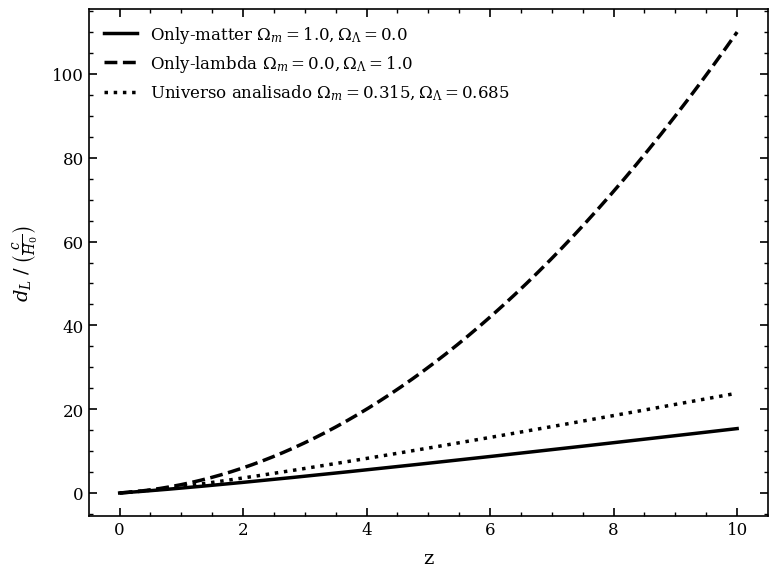


  > Gráficos de Distância de Luminosidade criados com sucesso!...


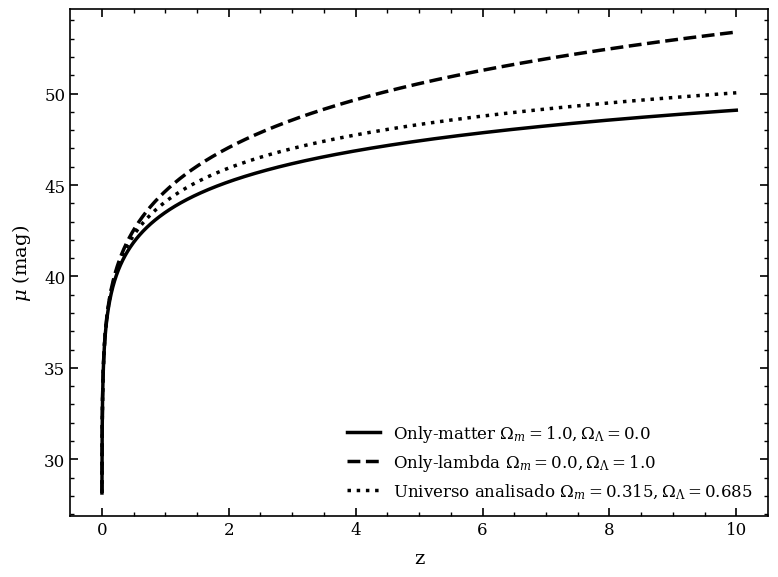


  > Gráficos de Módulo de Distância criados com sucesso!...

  > Rotina de criação de gráficos sobrepostos finalizada!...


In [21]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

# ? -----------------------------------------------------------------------------
# ?         GERANDO DADOS DOS UNIVERSOS ANALISADOS
# ? -----------------------------------------------------------------------------

try:
    header("Iniciando comparison plot...")
    status("Iniciando 1a análise")
    main(Omega_M, Omega_EE, w, z, z_step, "custom")
    bar()
    status("Iniciando 2a análise")
    main(1, 0, -1, z, z_step, "M")
    bar()
    status("Iniciando 3a análise")
    main(0, 1, -1, z, z_step, "EE")
    bar()
    status("Todas as análises terminadas!")
except Exception as e:
    status(f"Um erro foi encontrado ao tentar executar a rotina principal. Erro: {e}")

# ? -----------------------------------------------------------------------------
# ?         GERANDO GRÁFICOS PARA DISTÂNCIA DE LUMINOSIDADE
# ? -----------------------------------------------------------------------------

try:
    status("Iniciando criação de gráficos de Distância de Luminosidade")
    dadosM = "DLdadosM.txt"
    dadosEE = "DLdadosEE.txt"
    dadosMEE = f"DLdados.txt"
    x1 = load_data(f"data/DLdadosM.txt")[0]
    x2 = load_data(f"data/DLdadosEE.txt")[0]
    x3 = load_data(f"data/DLdados.txt")[0]
    y1 = load_data(f"data/DLdadosM.txt")[1] / (c / H0)
    y2 = load_data(f"data/DLdadosEE.txt")[1] / (c / H0)
    y3 = load_data(f"data/DLdados.txt")[1] / (c / H0)
    ppplot(
        True,
        x1,
        y1,
        x2,
        y2,
        x3,
        y3,
        r"Only-matter $\Omega_m=1.0, \Omega_\Lambda=0.0$",
        r"Only-lambda $\Omega_m=0.0, \Omega_\Lambda=1.0$",
        rf"Universo analisado $\Omega_m={Omega_M}, \Omega_\Lambda={Omega_EE}$",
        "Comparação de Distâncias de Luminosidade",
        "z",
        r"$d_L \; /\; \left(\frac{c}{H_0}\right)$",
        espessura=2.5,
    )
    status("Gráficos de Distância de Luminosidade criados com sucesso!")
except Exception as e:
    status(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Distância de luminosidade. Erro: {e}"
    )

# ? -----------------------------------------------------------------------------
# ?         GERANDO GRÁFICOS PARA MÓDULO DE DISTÂNCIA
# ? -----------------------------------------------------------------------------

try:
    dadosM = "MUdadosM.txt"
    dadosEE = "MUdadosEE.txt"
    dadosMEE = f"MUdados.txt"
    x1 = load_data(f"data/MUdadosM.txt")[0]
    x2 = load_data(f"data/MUdadosEE.txt")[0]
    x3 = load_data(f"data/MUdados.txt")[0]
    y1 = load_data(f"data/MUdadosM.txt")[1]
    y2 = load_data(f"data/MUdadosEE.txt")[1]
    y3 = load_data(f"data/MUdados.txt")[1]
    ppplot(
        True,
        x1,
        y1,
        x2,
        y2,
        x3,
        y3,
        r"Only-matter $\Omega_m=1.0, \Omega_\Lambda=0.0$",
        r"Only-lambda $\Omega_m=0.0, \Omega_\Lambda=1.0$",
        rf"Universo analisado $\Omega_m={Omega_M}, \Omega_\Lambda={Omega_EE}$",
        "Comparação de Módulos e Distância",
        "z",
        r"$\mu$ (mag)",
    )
    status("Gráficos de Módulo de Distância criados com sucesso!")
except Exception as e:
    status(
        f"Um erro foi encontrado ao tentar fazer a sobreposição dos gráficos de Módulo de Distância. Erro: {e}"
    )

status("Rotina de criação de gráficos sobrepostos finalizada!")


INFERENCE - Relações estattísticas de determinação de parâmetros com daods ( z , $\mu$ , $\sigma_\mu$ )


                    INFERÊNCIA DE DADOS                     
------------------------------------------------------------

  > Iniciando a varredura 1D...


PROGRESSO:   0%|          | 0/100 [00:00<?, ?it/s]


  > Varredura 1D finalizada com sucesso!...
      Qui-quadrado mínimo (chi2_min) = 542.6840342993312
      Densidade de materia Bestfit (BF_Omega_M) = 0.2700000000000001
      Densidade de energia Bestfit (BF_Omega_EE) = 0.73

  > Iniciando cálculo de incertezas...
      Qui-quadrado 1_sigma (chi2_1_sigma) = 543.6840342993312
      Densidade de materia 1_sigma_esquerda (L_1_sigma_Omega_M) = 0.26000000000000006
      Densidade de energia 1_sigma_esquerda (L_1_sigma_Omega_EE) = 0.74
      Densidade de materia 1_sigma_direita (R_1_sigma_Omega_M) = 0.2800000000000001
      Densidade de energia 1_sigma_direita (R_1_sigma_Omega_EE) = 0.72
      Qui-quadrado 2_sigma (chi2_2_sigma) = 546.6840342993312
      Densidade de materia 2_sigma_esquerda (L_2_sigma_Omega_M) = 0.24000000000000007
      Densidade de energia 2_sigma_esquerda (L_2_sigma_Omega_EE) = 0.7599999999999999
      Densidade de materia 2_sigma_direita (R_2_sigma_Omega_M) = 0.3000000000000001
      Densidade de energia 2_sigma_direi

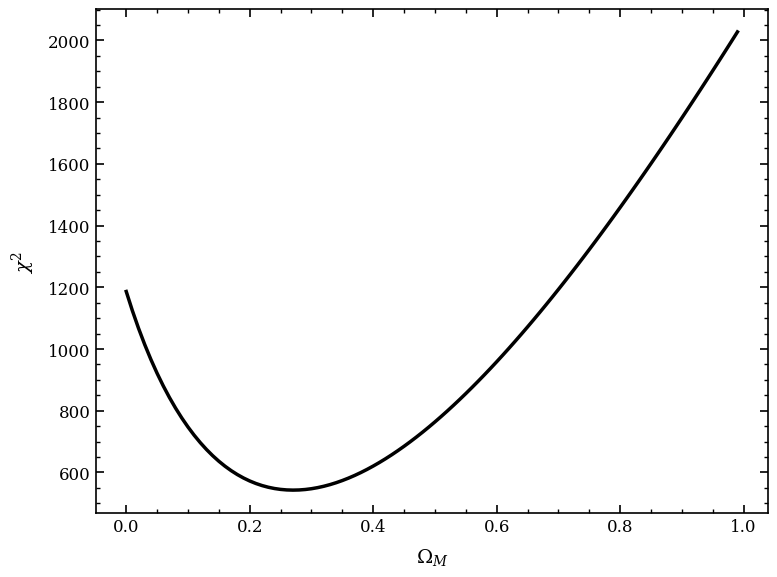


  > Criação de gráficos finalizada!...

  > Iniciando cálculo da probabilidade de Omega_EE > 0.5...
      Probabilidade de Energia Escura (P_ee) = 1.0
      Energia Escura do universo superior a 50% = confirmada!

  > Iniciando a varredura 2D...


PROGRESSO:   0%|          | 0/100 [00:00<?, ?it/s]


  > Varredura 2D finalizada com sucesso!...
      Qui-quadrado mínimo (2dchi2_min) = 542.6264698489487
      Densidade de materia Bestfit (2dBF_Omega_M) = 0.2900000000000001
      Densidade de energia Bestfit (2dBF_Omega_EE) = 0.7500000000000004

  > Iniciando cálculo de incertezas...
      Qui-quadrado 1_sigma (chi2_1_sigma) = 544.9264698489486
      Qui-quadrado 2_sigma (chi2_2_sigma) = 548.8064698489486
      Qui-quadrado 3_sigma (chi2_3_sigma) = 554.4564698489487

  > Iniciando criação de gráfico de distribuição qui-quadrado...


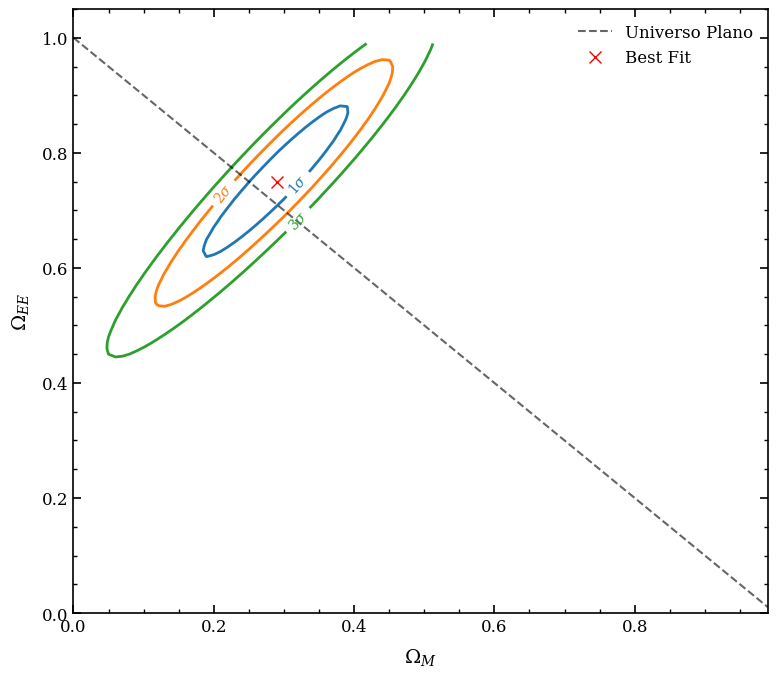


  > Criação de gráficos finalizada!...

  > Iniciando quebra de degenerescência: Aplicando Prior da CMB na malha 2D...

  > Quebra de degenerecência finalizada com sucesso!...
      Qui-quadrado mínimo com quebra de degenerecência (2dchi2_minPRIOR) = 542.6727153511614
      Densidade de materia Bestfit com quebra de degenerecência (2dBF_Omega_MPRIOR) = 0.3000000000000001
      Densidade de energia Bestfit com quebra de degenerecência (2dBF_Omega_EEPRIOR) = 0.7600000000000005

  > Iniciando cálculo de incertezas...

  > Iniciando criação de gráfico de distribuição qui-quadrado...


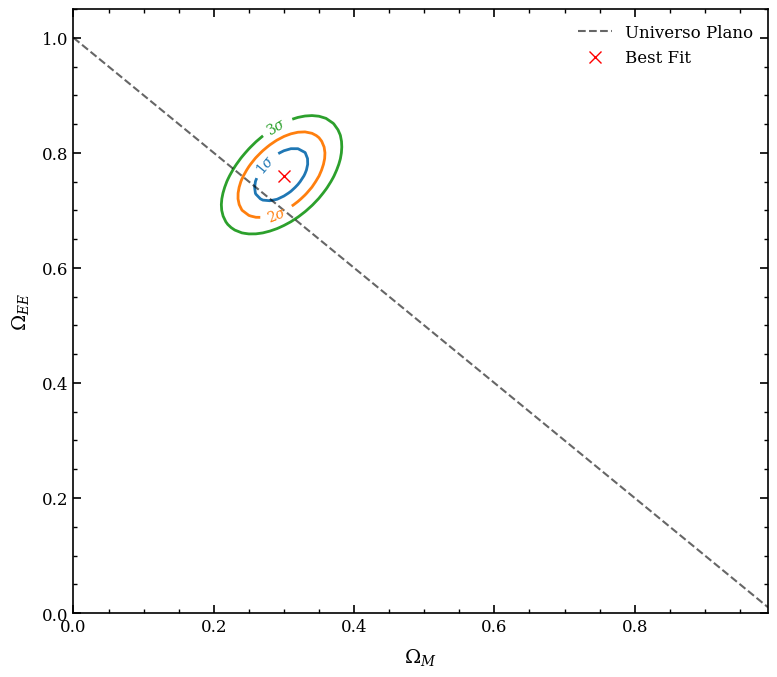


  > Criação de gráficos finalizada!...

  > Iniciando cálculo da probabilidade de aceleração...
      Probabilidade de Aceleração (P_acel) = 1.0
      Aceleração do universo superior a 3-sigma = confirmada!

  > Iniciando varredura bidimensional (OMEGA_M vs W)...


PROGRESSO:   0%|          | 0/150 [00:00<?, ?it/s]

      Qui-quadrado mínimo (2dchi2_min) = 542.6595886208559
      Parâmetro da equação de estado Bestfit (2dBF_w) = -1.0199999999999998
      Densidade de matéria Bestfit (2dBF_Omega_M) = 0.2800000000000001

  > Iniciando cálculo de incertezas...
      Qui-quadrado 1_sigma (chi2_1_sigma) = 544.9595886208558
      Qui-quadrado 2_sigma (chi2_2_sigma) = 548.8395886208558
      Qui-quadrado 3_sigma (chi2_3_sigma) = 554.4895886208559

  > Iniciando criação de gráfico de distribuição qui-quadrado...


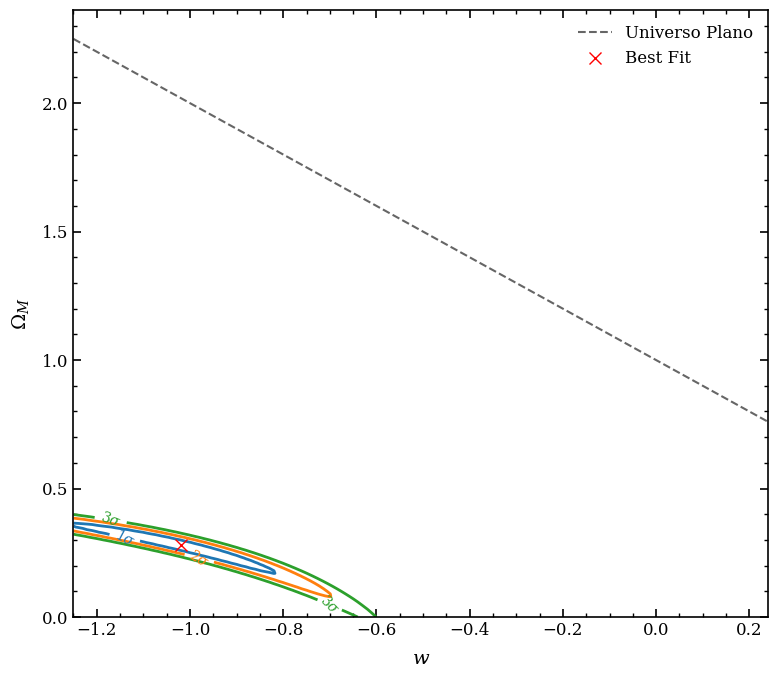


  > Criação de gráficos finalizada!...


In [22]:

# * =============================================================================
# * ROTINA PRINCIPAL
# * =============================================================================

obsdatalist = load_obs_data("obs_data.txt")
z_list = obsdatalist[0]
mu_obs_list = obsdatalist[1]
ERROmu_obs_list = obsdatalist[2]
header("Inferência de dados")

# ? -----------------------------------------------------------------------------
# ?         VARREDURA UNIDIMENSIONAL
# ? -----------------------------------------------------------------------------

status("Iniciando a varredura 1D")
omega_list = []
omega_var = mesh_inter_omega[0]
while omega_var < mesh_inter_omega[1]:
    omega_list.append(omega_var)
    omega_var = omega_var + meshgrid_step
var1d = varredura_1D(omega_list, mu_obs_list, ERROmu_obs_list, z_list, w)
status("Varredura 1D finalizada com sucesso!")
chi_min = np.min(var1d[0])
INDchi_min = np.argmin(var1d[0])
param("Qui-quadrado mínimo (chi2_min)", chi_min)
param("Densidade de materia Bestfit (BF_Omega_M)", var1d[1][INDchi_min])
param("Densidade de energia Bestfit (BF_Omega_EE)", var1d[2][INDchi_min])
status("Iniciando cálculo de incertezas")
chi_sigma1 = chi_min + 1
chi_sigma2 = chi_min + 4
chi_sigma3 = chi_min + 9
R_INDchi_sigma1 = np.abs(var1d[0][INDchi_min:] - chi_sigma1).argmin() + INDchi_min
L_INDchi_sigma1 = np.abs(var1d[0][:INDchi_min] - chi_sigma1).argmin()
R_INDchi_sigma2 = np.abs(var1d[0][INDchi_min:] - chi_sigma2).argmin() + INDchi_min
L_INDchi_sigma2 = np.abs(var1d[0][:INDchi_min] - chi_sigma2).argmin()
R_INDchi_sigma3 = np.abs(var1d[0][INDchi_min:] - chi_sigma3).argmin() + INDchi_min
L_INDchi_sigma3 = np.abs(var1d[0][:INDchi_min] - chi_sigma3).argmin()
param("Qui-quadrado 1_sigma (chi2_1_sigma)", chi_sigma1)
param(
    "Densidade de materia 1_sigma_esquerda (L_1_sigma_Omega_M)",
    var1d[1][L_INDchi_sigma1],
)
param(
    "Densidade de energia 1_sigma_esquerda (L_1_sigma_Omega_EE)",
    var1d[2][L_INDchi_sigma1],
)
param(
    "Densidade de materia 1_sigma_direita (R_1_sigma_Omega_M)",
    var1d[1][R_INDchi_sigma1],
)
param(
    "Densidade de energia 1_sigma_direita (R_1_sigma_Omega_EE)",
    var1d[2][R_INDchi_sigma1],
)
param("Qui-quadrado 2_sigma (chi2_2_sigma)", chi_sigma2)
param(
    "Densidade de materia 2_sigma_esquerda (L_2_sigma_Omega_M)",
    var1d[1][L_INDchi_sigma2],
)
param(
    "Densidade de energia 2_sigma_esquerda (L_2_sigma_Omega_EE)",
    var1d[2][L_INDchi_sigma2],
)
param(
    "Densidade de materia 2_sigma_direita (R_2_sigma_Omega_M)",
    var1d[1][R_INDchi_sigma2],
)
param(
    "Densidade de energia 2_sigma_direita (R_2_sigma_Omega_EE)",
    var1d[2][R_INDchi_sigma2],
)
param("Qui-quadrado 3_sigma (chi2_3_sigma)", chi_sigma3)
param(
    "Densidade de materia 3_sigma_esquerda (L_3_sigma_Omega_M)",
    var1d[1][L_INDchi_sigma3],
)
param(
    "Densidade de energia 3_sigma_esquerda (L_3_sigma_Omega_EE)",
    var1d[2][L_INDchi_sigma3],
)
param(
    "Densidade de materia 3_sigma_direita (R_3_sigma_Omega_M)",
    var1d[1][R_INDchi_sigma3],
)
param(
    "Densidade de energia 3_sigma_direita (R_3_sigma_Omega_EE)",
    var1d[2][R_INDchi_sigma3],
)
status("Cálculo de incertezas finalizado!")
status("Iniciando criação de gráfico de distribuição qui-quadrado")
plot(True, var1d[1], var1d[0], "distQuiQuad", r"$\Omega_M$", r"$\chi^2$")
status("Criação de gráficos finalizada!")

# ? -----------------------------------------------------------------------------
# ?         PROBABILIDADE DE ENERGIA ESCURA
# ? -----------------------------------------------------------------------------

status("Iniciando cálculo da probabilidade de Omega_EE > 0.5")
prob_ee = veross1d(var1d[0], chi_min, var1d[2])
if prob_ee > 0.5:
    ee1d = "confirmada!"
else:
    ee1d = "não confirmada!"
param("Probabilidade de Energia Escura (P_ee)", prob_ee)
param("Energia Escura do universo superior a 50%", ee1d)

# ? -----------------------------------------------------------------------------
# ?         VARREDURA BIDIMENSIONAL
# ? -----------------------------------------------------------------------------

status("Iniciando a varredura 2D")
omegaM_list = []
omegaM_var = mesh_inter_omega[0]
while omegaM_var < mesh_inter_omega[1]:
    omegaM_list.append(omegaM_var)
    omegaM_var = omegaM_var + meshgrid_step
omegaEE_list = omegaM_list
var2d = varredura_2D(omegaM_list, omegaEE_list, mu_obs_list, ERROmu_obs_list, z_list, w)
status("Varredura 2D finalizada com sucesso!")
chi2d_min = np.min(var2d)
MINDchi2d_min, EEINDchi2d_min = np.unravel_index(np.argmin(var2d), var2d.shape)
param("Qui-quadrado mínimo (2dchi2_min)", chi2d_min)
param("Densidade de materia Bestfit (2dBF_Omega_M)", omegaM_list[MINDchi2d_min])
param("Densidade de energia Bestfit (2dBF_Omega_EE)", omegaEE_list[EEINDchi2d_min])
status("Iniciando cálculo de incertezas")
chi2d_sigma1 = chi2d_min + 2.30
chi2d_sigma2 = chi2d_min + 6.18
chi2d_sigma3 = chi2d_min + 11.83
param("Qui-quadrado 1_sigma (chi2_1_sigma)", chi2d_sigma1)
param("Qui-quadrado 2_sigma (chi2_2_sigma)", chi2d_sigma2)
param("Qui-quadrado 3_sigma (chi2_3_sigma)", chi2d_sigma3)
niveis = [chi2d_sigma1, chi2d_sigma2, chi2d_sigma3]
status("Iniciando criação de gráfico de distribuição qui-quadrado")
elipse_plot(True, omegaM_list, omegaEE_list, var2d, niveis, "elipse_var")
status("Criação de gráficos finalizada!")

# ? -----------------------------------------------------------------------------
# ?         QUEBRA DE DEGENERECÊNCIA (PRIOR DA CMB)
# ? -----------------------------------------------------------------------------

status("Iniciando quebra de degenerescência: Aplicando Prior da CMB na malha 2D")
var2dPRIOR = quebra_degenerecencia(
    omegaM_list, omegaEE_list, var2d, Omega_K_obs, ERROOmega_K_obs
)
status("Quebra de degenerecência finalizada com sucesso!")
chi2d_minPRIOR = np.min(var2dPRIOR)
MINDchi2d_minPRIOR, EEINDchi2d_minPRIOR = np.unravel_index(
    np.argmin(var2dPRIOR), var2dPRIOR.shape
)
param(
    "Qui-quadrado mínimo com quebra de degenerecência (2dchi2_minPRIOR)", chi2d_minPRIOR
)
param(
    "Densidade de materia Bestfit com quebra de degenerecência (2dBF_Omega_MPRIOR)",
    omegaM_list[MINDchi2d_minPRIOR],
)
param(
    "Densidade de energia Bestfit com quebra de degenerecência (2dBF_Omega_EEPRIOR)",
    omegaEE_list[EEINDchi2d_minPRIOR],
)
status("Iniciando cálculo de incertezas")
chi2d_sigma1PRIOR = chi2d_minPRIOR + 2.30
chi2d_sigma2PRIOR = chi2d_minPRIOR + 6.18
chi2d_sigma3PRIOR = chi2d_minPRIOR + 11.83
niveisPRIOR = [chi2d_sigma1PRIOR, chi2d_sigma2PRIOR, chi2d_sigma3PRIOR]
status("Iniciando criação de gráfico de distribuição qui-quadrado")
elipse_plot(True, omegaM_list, omegaEE_list, var2dPRIOR, niveisPRIOR, "elipsePRIOR_var")
status("Criação de gráficos finalizada!")

# ? -----------------------------------------------------------------------------
# ?         PROBABILIDADE DE ACELERAÇÃO 2D
# ? -----------------------------------------------------------------------------

status("Iniciando cálculo da probabilidade de aceleração")
prob_aceleracao = veross2d(var2dPRIOR, chi2d_minPRIOR, omegaM_list, omegaEE_list, w)
if prob_aceleracao > 0.997:
    acel = "confirmada!"
else:
    acel = "não confirmada!"
param("Probabilidade de Aceleração (P_acel)", prob_aceleracao)
param("Aceleração do universo superior a 3-sigma", acel)

# ? -----------------------------------------------------------------------------
# ?         VARREDURA BIDIMENSIONAL - OMEGA_M VS W
# ? -----------------------------------------------------------------------------

status("Iniciando varredura bidimensional (OMEGA_M vs W)")
w_list = []
w_var = mesh_inter_w[0]
while w_var < mesh_inter_w[1]:
    w_list.append(w_var)
    w_var = w_var + meshgrid_step
var2dOW=varreduraOW(w_list, omegaM_list, mu_obs_list, ERROmu_obs_list, z_list)
chi2dOW_min = np.min(var2dOW)
WINDchi2dOW_min, MINDchi2dOW_min = np.unravel_index(np.argmin(var2dOW), var2dOW.shape)
param("Qui-quadrado mínimo (2dchi2_min)", chi2dOW_min)
param("Parâmetro da equação de estado Bestfit (2dBF_w)", w_list[WINDchi2dOW_min])
param("Densidade de matéria Bestfit (2dBF_Omega_M)", omegaM_list[MINDchi2dOW_min])
status("Iniciando cálculo de incertezas")
chi2dOW_sigma1 = chi2dOW_min + 2.30
chi2dOW_sigma2 = chi2dOW_min + 6.18
chi2dOW_sigma3 = chi2dOW_min + 11.83
param("Qui-quadrado 1_sigma (chi2_1_sigma)", chi2dOW_sigma1)
param("Qui-quadrado 2_sigma (chi2_2_sigma)", chi2dOW_sigma2)
param("Qui-quadrado 3_sigma (chi2_3_sigma)", chi2dOW_sigma3)
niveis = [chi2dOW_sigma1, chi2dOW_sigma2, chi2dOW_sigma3]
status("Iniciando criação de gráfico de distribuição qui-quadrado")
elipse_plot(True, w_list, omegaM_list, var2dOW, niveis, "elipse_varOW", r"$w$",r"$\Omega_M$")
status("Criação de gráficos finalizada!")